# Анализ данных о диабете

## Задание 4. Загрузка и исследование данных

In [24]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

# Для разделения данных и масштабирования
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Модели и метрики
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve

# Настроим отображение графиков
%matplotlib inline
sns.set(style='whitegrid', context='notebook')

In [7]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [17]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Пропусков нету, двигаемся дальше

**Первичный анализ данных:** Мы имеем табличный датасет о заболеваемости диабетом девушек
Датасет содержит следующие поля:
1. Pregnancies - беременость , немного не понимаю в чем суть этого столбца и чем являются цифры. Предположу, что это статус беремености n = 0 - нету.
 n => 1 - есть.
2. Glucose - уровень глюкозы в крови. Скорее всего измерялся в мг/дл. Норма натощак 79-110 . После еды до 140 мг/дл. В некоторых случаях глюкоза не измерлась
3. BloodPressure - кровяное давление. Измеряется в мм.рт.ст . Норма 120 - КСД / 80 - КДД. В некоторых случаях АД не измерялось 
4. SkinThickness - толщина кожи
5. Insulin - кол-во инсулина в крови  Норма 2,6 - 24,9 мкЕд/мл. В некоторых случаях не измерялось
6. BMI - ИМТ. Норма  ИМТ 18,5–24,9 кг/м².
7. DiabetesPedigreeFunction	  - Функция родословности диабета, наследственное значение диабета
8. Age - возраст
9. Outcome - целевой признак (Outcome), где Outcome=1 означает наличие диабета, а Outcome=0 — его отсутствие.

## Задание 5. Корреляционный анализ 

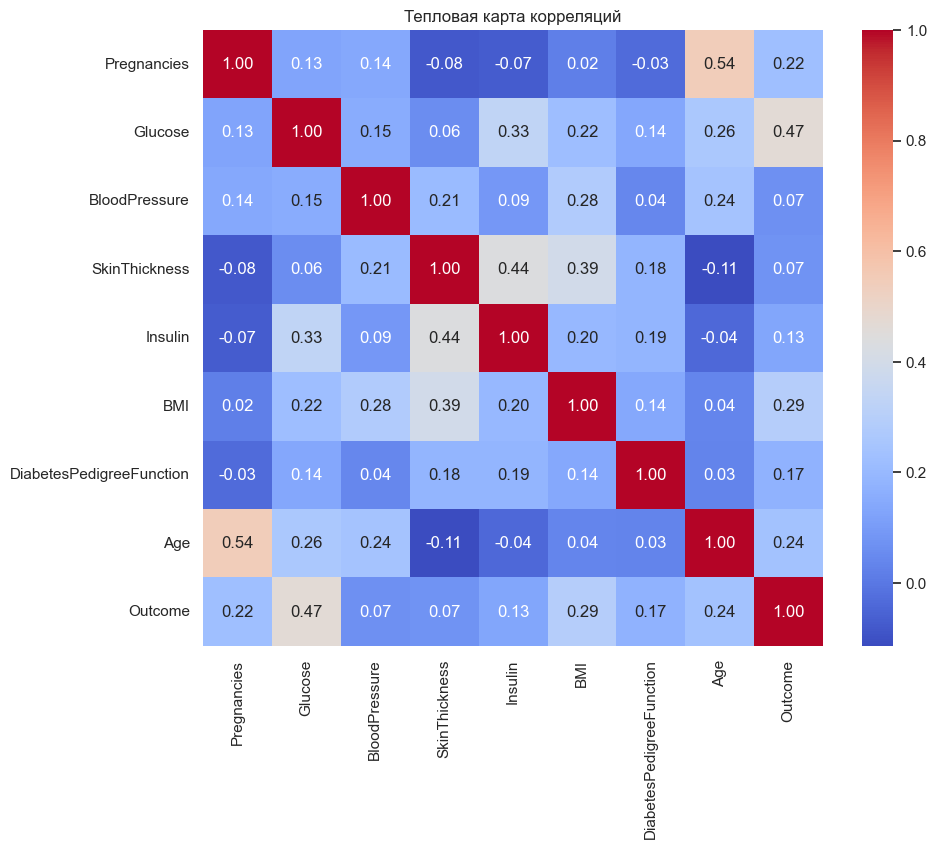

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [31]:
corr_matrix = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot = True, fmt=".2f", cmap="coolwarm")
plt.title("Тепловая карта корреляций")
plt.show()

print(corr_matrix['Outcome'].sort_values(ascending=False))

**Что такое корреляция?**
Корреляция измеряет степень и направление взаимосвязи между двумя переменными. Основные моменты:

Значения коэффициента корреляции могут варьироваться от -1 до +1:

+1 означает полную положительную корреляцию (при увеличении одной переменной другая увеличивается пропорционально).
-1 означает полную отрицательную корреляцию (при увеличении одной переменной другая уменьшается пропорционально).
0 говорит об отсутствии линейной зависимости между переменными.
Положительная корреляция: если две переменные растут вместе (например, с повышением уровня глюкозы может увеличиваться риск развития диабета).

Отрицательная корреляция: если одна переменная растёт, а другая уменьшается (например, при некоторых наборах данных увеличение физической активности может снижать риск развития диабета).



**Интерпретация результатов корреляционного анализа**
На что обратить внимание:
Сильная корреляция между признаками:
Если два признака имеют высокий коэффициент корреляции (например, > 0,7 или < -0,7), это может указывать на то, что они предоставляют схожую информацию. В моделях может возникнуть проблема мультиколлинеарности, которую следует учитывать при построении прогностических моделей.

Корреляция с целевым признаком:
Особое внимание уделяется признакам, которые коррелируют с целевой переменной (например, наличием диабета). Например, если Glucose имеет высокую положительную корреляцию с Outcome, то повышение уровня глюкозы, вероятно, связано с повышенным риском развития диабета.

Отрицательные корреляции:
Если признак коррелирует с целевым признаком отрицательно, это означает, что увеличение этого признака может быть связано с пониженной вероятностью наступления события (например, наличия заболевания).

Отсутствие корреляции:
Низкие коэффициенты корреляции (близкие к 0) указывают на слабую или отсутствующую линейную зависимость. Однако стоит помнить, что между переменными может быть нелинейная зависимость, которую не выявит коэффициент Пирсона.

**В нашем случае следующие признаки сильно коррелируют с Outcome: Glucosa, BMI, Age, Pregnancies**

________________________________________________________________________________________________________________________________________________________

Построим парные графики для этих данных 

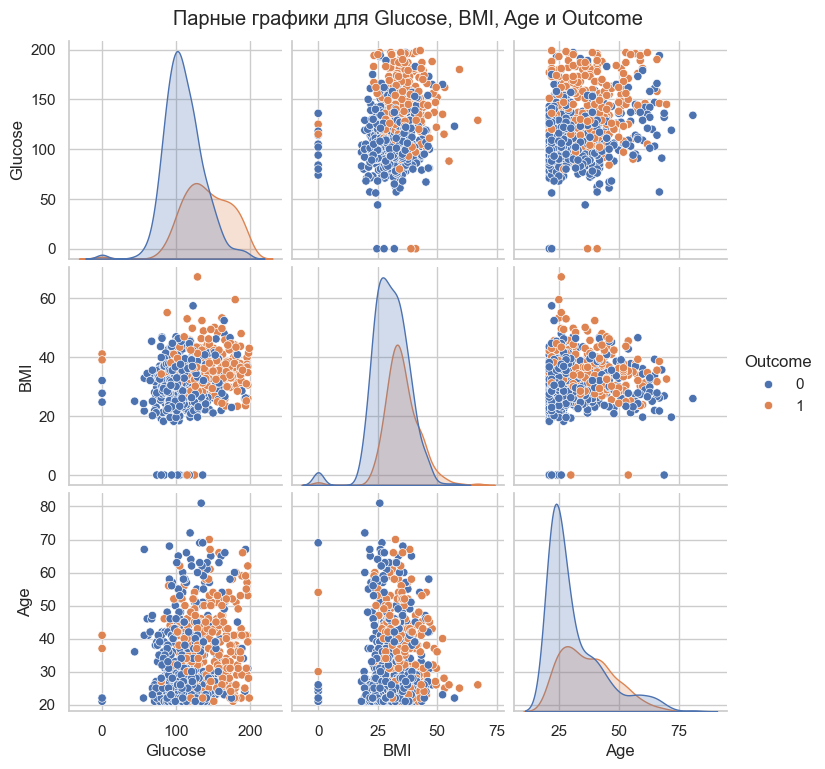

In [49]:
# Для парных графиков выберем наиболее значимые признаки по корреляционному анализу.
# Например, выберем 'Glucose', 'BMI', 'Age' и 'Outcome'
sns.pairplot(df[['Glucose', 'BMI', 'Age', 'Outcome']], hue='Outcome', diag_kind='kde')
plt.suptitle("Парные графики для Glucose, BMI, Age и Outcome", y=1.02)
plt.show()

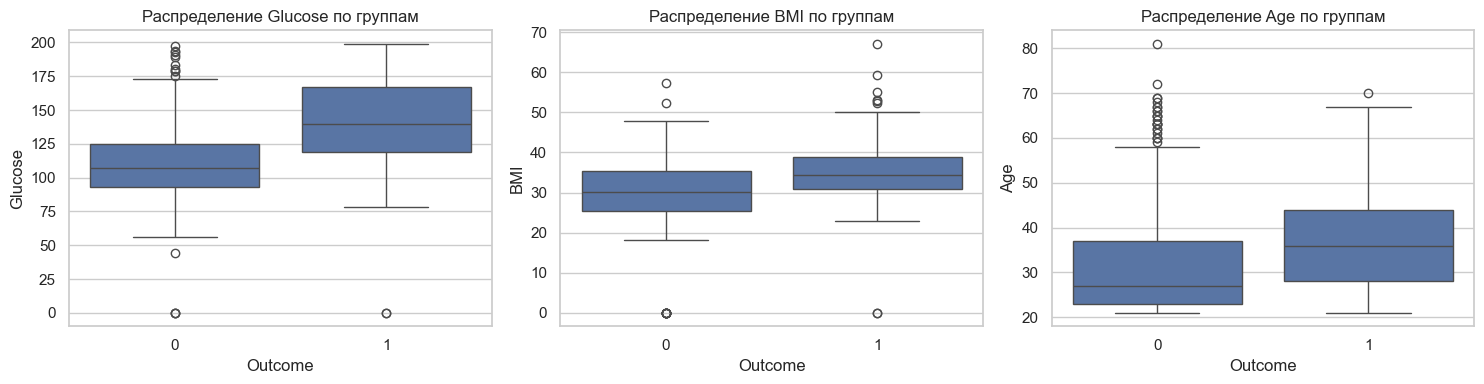

In [57]:
features_to_plot = ['Glucose', 'BMI', 'Age']
plt.figure(figsize=(15,4))
for i, feature in enumerate(features_to_plot):
    plt.subplot(1, len(features_to_plot), i+1)
    sns.boxplot( x = 'Outcome', y = feature, data = df)
    plt.title(f"Распределение {feature} по группам")
plt.tight_layout()
plt.show()

**Пояснения**:
**В нашем случае следующие признаки сильно коррелируют с Outcome: Glucosa, BMI, Age, Pregnancies**

**В нашем случае следующие признаки имеют слабую корреляцию с Outcome: Insulin, SkinThickness, BloodPressure**

Средняя корреляция характерна для DiabetesPedigreeFunction

Сахарный диабет — группа эндокринных заболеваний, связанных с нарушением усвоения глюкозы вследствие абсолютной или относительной недостаточности гормона инсулина. В результате развивается гипергликемия — стойкое увеличение содержания глюкозы в крови. 

Соответсвено: 
1. Глюкоза ключевой фактор в формировании диабет, т.к непосредсвтенно  инсулинозависимый/независимый  транспорт глюкозы в ткань и будет формировать диабет.
2. ИМТ - индекс массы тела. При высоком содержании адипоцитов , будет гиперсекреция и гиперпродукция лептина, который будет способстовать пищевому поведению, оказывая восходящие активрующие влияния на подкорковые и корковые представительства . Пищевое поведение сулит повышенное содержение глюкозы в крови
3. Возраст - старость настпуает с 60 лет, соотвествено все процессы жизнедеятльности будут приходить в упадок
4. Беременость - кординальное изменениние женского организма, гормональные изменения.

Соответвено, низкая корреляция:
1. Инсулин - естб диабет двух типов инсулинозависимый и независыимый ( соотвествено первый и второй тип) и при инсулинонезависимом диабете, корреляция  инсулина с Outcome будет очень низкая.
2. Толщина кожи  имеет связь с ИМТ. Т.к напрямую связана с ПЖК.
3. Кровяное давление - Слабая первостепенная связь с диабетом. Хотя имеется выоская корреляция к ИМТ. ( При росте ИМТ, АД увеличивается)

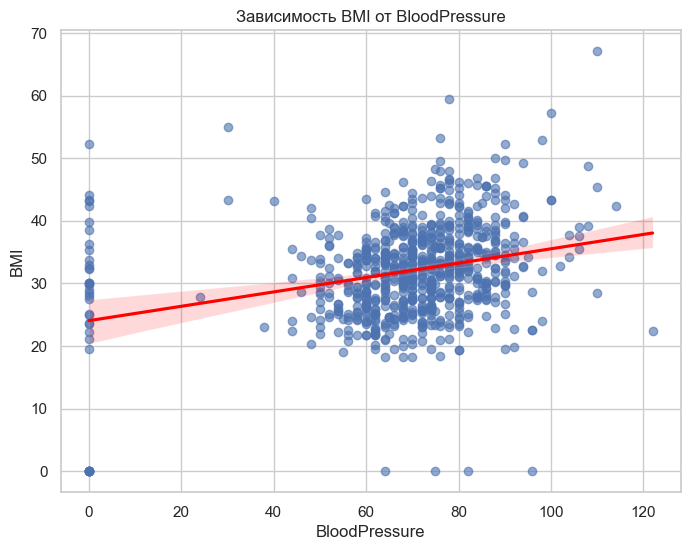

In [102]:
plt.figure(figsize=(8, 6))
sns.regplot(x='BloodPressure', y='BMI', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Зависимость BMI от BloodPressure')
plt.xlabel = 'BloodPressure'
plt.ylabel = 'BMI'
plt.show()

## Задание 6. Подготовка данных для обучения моделей

In [110]:
X = df.drop("Outcome", axis = 1)
y = df["Outcome"]

#Разделение данных на обучающую и тестовую выборки

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state  = 42, 
    stratify=y
)

# Проверка распределения целевого признака

print("Распределение в обучающей выборке:")
print(y_train.value_counts(normalize=True))
print("\nРаспределение в тестовой выборке:")
print(y_test.value_counts(normalize=True))

#Масштабирование числовых признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Преобразование масштабированных данных обратно в DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index = X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index = X_test.index)

Распределение в обучающей выборке:
Outcome
0    0.651769
1    0.348231
Name: proportion, dtype: float64

Распределение в тестовой выборке:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


## Задание 7. Построение и оценка базовой модели логистической регрессии

Логистическая регрессия — это метод, который используется для бинарной классификации. Он пытается найти оптимальные коэффициенты для линейной комбинации признаков, чтобы предсказать вероятность принадлежности объекта к тому или иному классу (в нашем случае: наличие или отсутствие диабета).

In [162]:
# Инициализируем модель логистической регрессии
log_reg = LogisticRegression(random_state=42, solver='liblinear')

# Обучаем модель на обучающих данных
log_reg.fit(X_train_scaled, y_train)

# Делаем прогнозы на тестовой выборке
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]  # Вероятности для класса 1

# Вычисляем метрики оценки
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Выводим результаты
print("Метрики качества базовой модели логистической регрессии:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Также можно вывести подробный отчет по классификации
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Метрики качества базовой модели логистической регрессии:
Accuracy:  0.7446
Precision: 0.6774
Recall:    0.5185
F1-score:  0.5874
ROC-AUC:   0.8380

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       150
           1       0.68      0.52      0.59        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.70       231
weighted avg       0.74      0.74      0.74       231



**Надо переобучить модель, сделать ее точнее**

In [164]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Определяем сетку гиперпараметров
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Инициализируем модель логистической регрессии с балансировкой классов
log_reg_balanced = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')

# Инициализируем GridSearchCV с метрикой ROC-AUC
grid_search_balanced = GridSearchCV(log_reg_balanced, param_grid, cv=5, scoring='roc_auc')
grid_search_balanced.fit(X_train_scaled, y_train)

print("Лучшие параметры (с class_weight='balanced'):")
print(grid_search_balanced.best_params_)

# Переобучаем модель с оптимальными параметрами
best_model_balanced = grid_search_balanced.best_estimator_
y_pred_balanced = best_model_balanced.predict(X_test_scaled)
y_pred_balanced_proba = best_model_balanced.predict_proba(X_test_scaled)[:, 1]

# Оценка оптимизированной модели
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
f1_balanced = f1_score(y_test, y_pred_balanced)
roc_auc_balanced = roc_auc_score(y_test, y_pred_balanced_proba)

print("\nМетрики оптимизированной модели (с class_weight='balanced'):")
print(f"Accuracy: {accuracy_balanced:.4f}")
print(f"Precision: {precision_balanced:.4f}")
print(f"Recall: {recall_balanced:.4f}")
print(f"F1-score: {f1_balanced:.4f}")
print(f"ROC-AUC: {roc_auc_balanced:.4f}")


Лучшие параметры (с class_weight='balanced'):
{'C': 1, 'penalty': 'l2'}

Метрики оптимизированной модели (с class_weight='balanced'):
Accuracy: 0.7662
Precision: 0.6517
Recall: 0.7160
F1-score: 0.6824
ROC-AUC: 0.8377


**Анализ результатов**

Разбор по метрикам:
Точность (0,7662) — 76,62%

Модель правильно классифицирует большинство примеров, но точность — не всегда лучший показатель, особенно если классы несбалансированы.
Учитывая, что это медицинская задача, в которой важно выявлять все случаи диабета, высокая точность сама по себе не гарантирует эффективность.
Точность (0,6517) — 65,17%

Точность показывает, насколько модель уверена в своих положительных прогнозах (когда модель говорит, что у пациента диабет, как часто она оказывается права).
Значение 65,17% означает, что около 35% случаев, предсказанных как диабет, являются ложными тревогами.
В медицине важен баланс Precision и Recall:
Высокий Precision → меньше ложных тревог (но
Низкий Precision → сли
65% — неплохой результат, но его можно улучшить, например, изменив порог прогнозирования.
Коэффициент запоминания (0,7160) — 71,60%

Recall измеряет, сколько реальных боль
Улучшенный показатель Recall (по сравнению с исходной моделью) говорит о том, что модель стала лучше
Однако 71,60% означает, что 28,40% диабетиков остались не выявленными. В медицинских задачах важно повышать показатель Recall, чтобы минимизировать риск пропуска заболевания.
F1-оценка (0,6824) — 68,24%

Это гармоническое среднее Precision и Recall.
Значение 0,68 говорит о сбалансированной модели, но есть куда расти.
В зависимости от задачи можно смещать баланс между Precision и Recall в нужную сторону (например, если мы хотим реже пропускать диабет, но готовы к ложным срабатываниям, нужно повысить Recall).
ROC-AUC (0,8377) — 83,77%

Очень хороший
ROC-AUC показывает, насколько хорошо модель отделяет больных от здоровых. 83,77% говорит о том, что модель делает это довольно точно.
Значение выше 0,80 уже считается хорошим, выше 0,90 — отличным
Выводы и возможные улучшения:
✅ Модель стала лучше по сравнению с базовой версией:

Точность выросла с 74,46% до 76,62%
Точность распознавания заметно улучшилась (с 51,85% до 71,60%) → теперь мы пропускаем меньше
ROC-AUC остаётся стабильным (83,80% → 83,77%), значит, модель по-прежнему хорошо разделяет классы
❗ Что можно улучшить дальше?

Дальнейшая оптимизация Precision vs Recall:

Если мы хотим ещё больше повысить Recall (и не пропускать диабетиков), можно снизить порог классификации (например, считать диабетиками всех, у кого вероятность > 0,4, а не
Если мы хотим повысить точность (и уменьшить количество ложных срабатываний), то, наоборот, нужно поднять порог (например, до 0,6).
Это можно сделать с помощью precision_recall_curve() из sklearn.metrics.
Попробовать более сложные модели:

Случайный лес или градиентный бустинг (XGBoost, LightGBM) часто показывают лучшие результаты, особенно если данные нелинейно разделимы.
Эти алгоритмы могут дать прирост точности, но требуют тщательной настройки.
Feature Engineering (поиск новых признаков):

Можно попробовать создать новые признаки, например:
Индекс инсулиновой резистентности
Отношение Glucose к BMI
Группировка возрастов и BMI (биннинг)
Дополнительная обработка данных:

Проверить распределение признаков и попробовать немонотонные преобразования (например, логарифмирование или полиномиальные признаки).
Использовать алгоритмы отбора признаков, чтобы оставить только самые значимые.
🔥 Итог:
Модель уже стала лучше, особенно по показателю Recall. Если задача — максимально снизить вероятность пропуска диабета, то стоит ещё сильнее увеличить показатель Recall (даже в ущерб Precision). Если мы хотим сбалансированную модель, то текущее качество уже достаточно хорошее, но можно попробовать более сложные алгоритмы.

1. Accuracy - точность. Доля правильно предсказанных наблюдений среди всех.
2. Precision (точность предсказаний):Доля истинно положительных прогнозов среди всех прогнозов, которые модель отнесла к положительному классу. Важно, когда ложные положительные прогнозы критичны.
3. Recall - полнота. Доля правильно предсказанных положительных наблюдений от общего числа истинно положительных объектов. Важно, если необходимо минимизировать количество ложных отрицаний.
4. F1-score - ф1 счет. Гармоническое среднее между точностью и полнотой. Используется, когда нужно сбалансировать эти две метрики.
5. ROC-AUC - Площадь под ROC-кривой (характеристикой приёмника). Эта метрика оценивает способность модели различать классы с помощью вероятностей. Чем ближе значение к 1, тем лучше модель различает классы.

## Задание 8. Использование модели

In [183]:
# Вывод коэффициентов логистической регрессии
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
})
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)
print("Коэффициенты модели логистической регрессии:")
print(coefficients)

Коэффициенты модели логистической регрессии:
                    Feature  Coefficient
1                   Glucose     1.120265
5                       BMI     0.708395
0               Pregnancies     0.455117
6  DiabetesPedigreeFunction     0.234108
7                       Age     0.095035
3             SkinThickness    -0.039378
4                   Insulin    -0.075778
2             BloodPressure    -0.201315


**Интерпретация**

Положительные коэффициенты указывают на прямую зависимость признака от вероятности наличия диабета, 
отрицательные – на обратную зависимость. Например, если коэффициент для Glucose положительный и высок, 
это означает, что при увеличении уровня глюкозы вероятность диабета растет.

Выводы:

Глюкоза  → Самый значимый фактор. Чем выше уровень глюкозы, тем выше вероятность диабета.
ИМТ  → Избыточный вес повышает риск.
Age  → С возрастом риск диабета растёт.
DiabetesPedigreeFunc → Генетическая предрасположенность также важна.
Инсулин  → Низкий уровень инсулина связан с низким риском развития диабета, но этот показатель может быть нестабильным.

Практическое применение:
**Коэффициенты помогают:**

Понять, какие признаки сильнее влияют на предсказание.
Упрощать модель, исключая слабые признаки.
Объяснить врачам и пациентам, почему модель делает то или иное предсказание.

In [1]:
# Создание функции для предсказания наличия диабета
def predict_diabetes(pregnancies, glucose, blood_pressure, skin_thickness, insulin, BMI, diabetes_pedigree_function, age):
    """
    Функция принимает значения признаков и возвращает вероятность наличия диабета.
    """
    # Создаем DataFrame из входных данных
    input_data = pd.DataFrame({
        "Pregnancies": [pregnancies],
        "Glucose": [glucose],
        "BloodPressure": [blood_pressure],
        "SkinThickness": [skin_thickness],
        "Insulin": [insulin],
        "BMI": [BMI],
        "DiabetesPedigreeFunction": [diabetes_pedigree_function],
        "Age": [age]
    })
    
    # Масштабируем входные данные, используя ранее обученный скейлер
    input_data_scaled = scaler.transform(input_data)
    
    # Получаем вероятность наличия диабета
    probability = log_reg.predict_proba(input_data_scaled)[0, 1]
    return probability

# Пример использования функции
example_probability = predict_diabetes(
    pregnancies=2,
    glucose=120,
    blood_pressure=70,
    skin_thickness=20,
    insulin=80,
    BMI=28.0,
    diabetes_pedigree_function=0.5,
    age=30
)
print(f"\nВероятность наличия диабета по примеру: {example_probability:.2f}")

NameError: name 'pd' is not defined

In [199]:
from sklearn.preprocessing import StandardScaler

# Создаём StandardScaler, обученный на тренировочных данных
scaler = StandardScaler()
scaler.fit(X_train)

def predict_diabetes(pregnancies, glucose, blood_pressure, skin_thickness, insulin, BMI, diabetes_pedigree_function, age):
    """
    Функция принимает значения признаков пациента и предсказывает вероятность наличия диабета.
    """
    # Создаём массив с входными данными
    input_data = np.array([[pregnancies, glucose, blood_pressure, skin_thickness, 
                            insulin, BMI, diabetes_pedigree_function, age]])
    
    # Масштабируем данные так же, как при обучении
    input_data_scaled = scaler.transform(input_data)
    
    # Делаем предсказание вероятности
    probability = log_reg.predict_proba(input_data_scaled)[0, 1]  # Берём вероятность класса "1" (диабет)
    
    # Определяем финальный диагноз
    prediction = 1 if probability > 0.5 else 0  # Порог можно менять, например, 0.4 для повышения Recall
    
    return {"probability": probability, "prediction": prediction}

# Пример использования функции
example_patient = predict_diabetes(2, 150, 70, 25, 100, 30.5, 0.5, 40)
print(f"Вероятность диабета: {example_patient['probability']:.2%}")
print(f"Диагноз: {'Диабет' if example_patient['prediction'] == 1 else 'Нет диабета'}")


Вероятность диабета: 45.16%
Диагноз: Нет диабета


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# Бонусное задание 9. Подбор гиперпараметров с использованием Grid Search

In [206]:
from sklearn.model_selection import GridSearchCV

# Определяем сетку гиперпараметров для логистической регрессии
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],  # Для l1 требуется solver 'liblinear'
    'solver': ['liblinear', 'saga']
}

# Инициализируем модель логистической регрессии
log_reg = LogisticRegression(random_state=42, solver='liblinear')

# Инициализируем GridSearchCV с метрикой ROC-AUC
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train_scaled, y_train)

print("Лучшие параметры по Grid Search:")
print(grid_search.best_params_)

# Переобучаем модель с оптимальными параметрами
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
y_pred_best_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Оценка оптимизированной модели
accuracy_best = accuracy_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_pred_best_proba)

print("\nМетрики оптимизированной модели:")
print(f"Accuracy: {accuracy_best:.2f}")
print(f"ROC-AUC: {roc_auc_best:.2f}")


Лучшие параметры по Grid Search:
{'C': 1, 'penalty': 'l2', 'solver': 'saga'}

Метрики оптимизированной модели:
Accuracy: 0.74
ROC-AUC: 0.84
